# Multi-Objective Reinforcement Learning
## Deep Sea Treasure: Exploración Completa de MORL

**Autores:** Juan Diego, Jessica, Daniel Barrero  
**Ambiente:** Deep Sea Treasure — MO-Gymnasium  
**Algoritmos:** Q-Learning Escalarizado · Pareto Q-Learning (PQL)

---

## 1. Introducción al Aprendizaje por Refuerzo Multiobjetivo (MORL)

### RL Clásico vs MORL

En el RL clásico, el agente recibe una **recompensa escalar** $r \in \mathbb{R}$ y maximiza:

$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k}$$

En **MORL**, el agente recibe un **vector de recompensas** $\vec{r} \in \mathbb{R}^n$, donde cada componente $r_i$ representa un objetivo diferente. El agente debe aprender a balancear estos objetivos, que generalmente están en conflicto.

### Dominancia de Pareto

Una política $\pi$ **domina** a $\pi'$ si es mejor o igual en todos los objetivos y estrictamente mejor en al menos uno:

$$\pi \succ \pi' \iff \forall i: V_i(\pi) \geq V_i(\pi') \quad \text{y} \quad \exists i: V_i(\pi) > V_i(\pi')$$

El **Frente de Pareto** $\mathcal{F}$ es el conjunto de todas las políticas no dominadas. Ningún punto del frente puede mejorar un objetivo sin empeorar otro.

### Dos Paradigmas de MORL

| Enfoque | Idea | Resultado | Limitación |
|---------|------|-----------|------------|
| **Escalarización** | $r_{\text{scalar}} = \mathbf{w}^\top \vec{r}$ | Una política por vector de pesos | Solo cubre la envolvente convexa |
| **Multi-política (PQL)** | Mantiene conjunto de Q-vectores no dominados | Todo el frente de Pareto | Mayor costo computacional |

### Hipervolumen

El **hipervolumen** mide la calidad del frente de Pareto encontrado. Dado un punto de referencia $\mathbf{r}_{\text{ref}}$ (peor que cualquier punto del frente):

$$HV(\mathcal{F}, \mathbf{r}_{\text{ref}}) = \lambda\left(\bigcup_{\vec{v} \in \mathcal{F}} [\vec{v}, \mathbf{r}_{\text{ref}}]\right)$$

A mayor hipervolumen → mejor frente de Pareto.

## 2. Instalación e Imports

In [24]:
!pip install mo-gymnasium morl-baselines moviepy --quiet


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL
from collections import defaultdict
import os
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
import imageio

os.makedirs('videos', exist_ok=True)

ENV_ID = 'deep-sea-treasure-v0'
print('Dependencias cargadas correctamente')

Dependencias cargadas correctamente


## 3. El Ambiente: Deep Sea Treasure (DST)

Deep Sea Treasure es un ambiente clásico de benchmarking para MORL introducido por Van Moffaert & Nowé (2014). Un **submarino** navega por el océano buscando tesoros enterrados en el fondo marino.

### Espacio de Estados

$$\mathcal{S} = \{(x, y) \mid x \in \{0,\ldots,10\},\ y \in \{0,\ldots,10\}\}$$

El estado es la posición del submarino en una cuadrícula de **11×11**. El submarino comienza en $(0, 0)$ (esquina superior izquierda).

### Espacio de Acciones

$$\mathcal{A} = \{0\ (\uparrow),\ 1\ (\downarrow),\ 2\ (\leftarrow),\ 3\ (\rightarrow)\}$$

4 acciones discretas de movimiento cardinal.

### Vector de Recompensas

$$\vec{r} = \begin{bmatrix} r_{\text{tiempo}} \\ r_{\text{tesoro}} \end{bmatrix} \in \mathbb{R}^2$$

- $r_{\text{tiempo}} = -1$ en cada paso de tiempo
- $r_{\text{tesoro}} = v > 0$ al llegar a un tesoro (0 en otro caso)

### El Trade-off Fundamental

$$\text{mayor profundidad} \Rightarrow \text{mayor } r_{\text{tesoro}} \text{ PERO menor } r_{\text{tiempo}}$$

Los tesoros más profundos son más valiosos pero requieren más pasos para alcanzarlos. Este conflicto hace del DST un benchmark ideal para MORL.

### Terminación

El episodio termina cuando el submarino llega a cualquier celda con tesoro.

In [26]:
env = mo_gym.make(ENV_ID, render_mode='rgb_array')

print('=' * 55)
print('   DEEP SEA TREASURE — INFORMACIÓN DEL AMBIENTE')
print('=' * 55)
print(f'\n  Espacio de estados  : {env.observation_space}')
print(f'  Espacio de acciones : {env.action_space}')
print(f'  Espacio de recomp.  : {env.unwrapped.reward_space}')
print(f'  Número de acciones  : {env.action_space.n}')

print('\n--- Ejemplo de interacción (política aleatoria) ---')
obs, _ = env.reset()
print(f'  Estado inicial: {obs}')
action_names = ['Arriba', 'Abajo', 'Izquierda', 'Derecha']

for step in range(6):
    action = env.action_space.sample()
    next_obs, r_vec, terminated, truncated, _ = env.step(action)
    print(f'  Paso {step+1}: {action_names[action]:>9} | obs={next_obs} | r={r_vec} | done={terminated}')
    obs = next_obs
    if terminated or truncated:
        break

env.close()

   DEEP SEA TREASURE — INFORMACIÓN DEL AMBIENTE

  Espacio de estados  : Box(0, 11, (2,), int32)
  Espacio de acciones : Discrete(4)
  Espacio de recomp.  : Box([ 0. -1.], [23.7 -1. ], (2,), float32)
  Número de acciones  : 4

--- Ejemplo de interacción (política aleatoria) ---
  Estado inicial: [0 0]
  Paso 1:   Derecha | obs=[0 1] | r=[ 0. -1.] | done=False
  Paso 2:     Abajo | obs=[1 1] | r=[ 0. -1.] | done=False
  Paso 3:     Abajo | obs=[2 1] | r=[ 8.2 -1. ] | done=True


## 4. Visualización del Ambiente

Grabamos episodios como videos MP4 que se muestran directamente en el notebook.

In [27]:
def record_episode(env_id, policy_fn, filepath, fps=5, max_steps=300):
    """Graba un episodio y lo guarda como MP4 con imageio. Retorna los frames."""
    env = mo_gym.make(env_id, render_mode='rgb_array')
    obs, _ = env.reset()
    frames = []
    terminated, truncated = False, False
    step = 0

    while not (terminated or truncated) and step < max_steps:
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = policy_fn(obs)
        obs, r_vec, terminated, truncated, _ = env.step(action)
        step += 1

    frame = env.render()
    if frame is not None:
        frames.append(frame)
    env.close()

    if not frames:
        print("  Advertencia: no se obtuvieron frames del ambiente.")
        return []

    mp4_path = filepath + ".mp4"
    writer = imageio.get_writer(mp4_path, fps=fps)
    for f in frames:
        writer.append_data(f)
    writer.close()
    print(f"  Video guardado: {mp4_path}  ({step} pasos, {len(frames)} frames)")
    return frames


def show_video(filepath, width=380):
    """Muestra un MP4 inline en el notebook."""
    mp4 = filepath + ".mp4"
    display(HTML(
        f'<video width="{width}" controls loop autoplay muted>'
        f'<source src="{mp4}" type="video/mp4"></video>'
    ))


In [28]:
print('Grabando episodio con politica aleatoria...')
record_episode(ENV_ID, lambda obs: np.random.randint(4), 'videos/dst_random', fps=5)
show_video('videos/dst_random')

Grabando episodio con politica aleatoria...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/dst_random.mp4  (3 pasos, 4 frames)


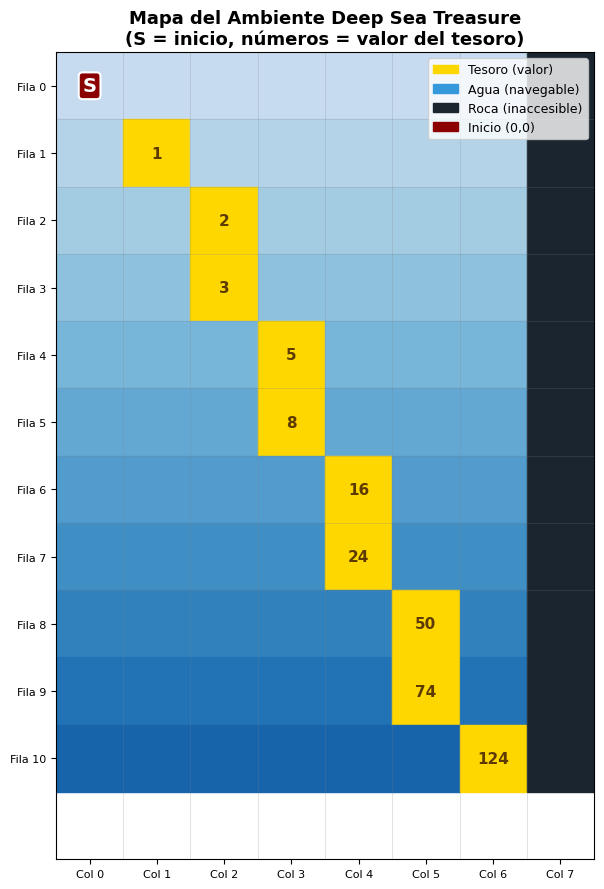

In [29]:
# Mapa del DST: posiciones (col, row) y valores de tesoros
DST_TREASURES = {
    (1, 1): 1,  (2, 2): 2,  (2, 3): 3,  (3, 4): 5,
    (3, 5): 8,  (4, 6): 16, (4, 7): 24, (5, 8): 50,
    (5, 9): 74, (6, 10): 124,
}

# Celdas accesibles (agua navegable)
DST_ACCESSIBLE = set()
for (tc, tr) in DST_TREASURES:
    for c in range(tc + 1):
        for r in range(tr + 1):
            DST_ACCESSIBLE.add((c, r))


def plot_dst_map(ax=None, show=True):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 9))

    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(11.5, -0.5)
    ax.set_aspect('equal')

    for col in range(8):
        for row in range(11):
            if (col, row) in DST_TREASURES:
                color = '#FFD700'
            elif (col, row) in DST_ACCESSIBLE:
                color = plt.cm.Blues(0.25 + 0.55 * (row / 10))
            else:
                color = '#1a252f'
            ax.add_patch(plt.Rectangle((col - 0.5, row - 0.5), 1, 1, color=color, zorder=1))

    for i in range(9):
        ax.axhline(i - 0.5, color='gray', lw=0.4, alpha=0.4, zorder=2)
        ax.axvline(i - 0.5, color='gray', lw=0.4, alpha=0.4, zorder=2)

    for (col, row), val in DST_TREASURES.items():
        ax.text(col, row, f'{val}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='#5d3a00', zorder=3)

    ax.text(0, 0, 'S', ha='center', va='center',
            fontsize=14, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', fc='darkred', ec='white', lw=1.5), zorder=4)

    ax.set_yticks(range(11))
    ax.set_yticklabels([f'Fila {i}' for i in range(11)], fontsize=8)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f'Col {i}' for i in range(8)], fontsize=8)

    legend = [
        mpatches.Patch(color='#FFD700', label='Tesoro (valor)'),
        mpatches.Patch(color='#3498DB', label='Agua (navegable)'),
        mpatches.Patch(color='#1a252f', label='Roca (inaccesible)'),
        mpatches.Patch(color='darkred', label='Inicio (0,0)'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=9)
    ax.set_title('Mapa del Ambiente Deep Sea Treasure\n(S = inicio, números = valor del tesoro)',
                 fontsize=13, fontweight='bold')

    if standalone and show:
        plt.tight_layout()
        plt.savefig('videos/dst_map.png', dpi=100, bbox_inches='tight')
        plt.show()


plot_dst_map()

## 5. El Frente de Pareto Verdadero del DST

El DST tiene un **frente de Pareto conocido analíticamente** con $\gamma = 1.0$ (sin descuento). Esto es una ventaja clave del benchmark: podemos medir exactamente cuántos puntos óptimos descubre cada algoritmo.

Hay **10 políticas óptimas de Pareto**, una por cada tesoro. Ninguna política puede mejorar el tiempo sin sacrificar valor del tesoro, ni viceversa.

In [30]:
# Frente de Pareto verdadero del DST (gamma=1.0)
# Columnas: [tiempo_acumulado, valor_tesoro]
# (el ambiente devuelve [tesoro, tiempo] — intercambiamos para graficar tiempo en X)
TRUE_PARETO = np.array([
    [ -1,  1], [ -3,  8], [ -5, 12], [ -7, 14], [ -8, 15],
    [ -9, 16], [-13, 20], [-14, 20], [-17, 22], [-19, 24],
], dtype=float)

try:
    env_tmp = mo_gym.make(ENV_ID)
    front_raw = env_tmp.unwrapped.pareto_front(gamma=1.0)
    env_tmp.close()
    if front_raw is not None and len(front_raw) > 0:
        # El ambiente retorna [tesoro, tiempo] → intercambiamos a [tiempo, tesoro]
        TRUE_PARETO = np.array(front_raw)[:, [1, 0]]
        print("Frente de Pareto obtenido del ambiente (columnas intercambiadas a [tiempo, tesoro]).")
except Exception as e:
    print(f"Usando frente de Pareto predefinido. ({e})")

print(f'\nFrente de Pareto verdadero ({len(TRUE_PARETO)} puntos):')
print(f'{"Tiempo":>10} | {"Tesoro":>10}')
print('-' * 25)
for pt in TRUE_PARETO:
    print(f'{pt[0]:>10.0f} | {pt[1]:>10.0f}')

Frente de Pareto obtenido del ambiente (columnas intercambiadas a [tiempo, tesoro]).

Frente de Pareto verdadero (10 puntos):
    Tiempo |     Tesoro
-------------------------
        -1 |          1
        -3 |          8
        -5 |         12
        -7 |         14
        -8 |         15
        -9 |         16
       -13 |         20
       -14 |         20
       -17 |         22
       -19 |         24


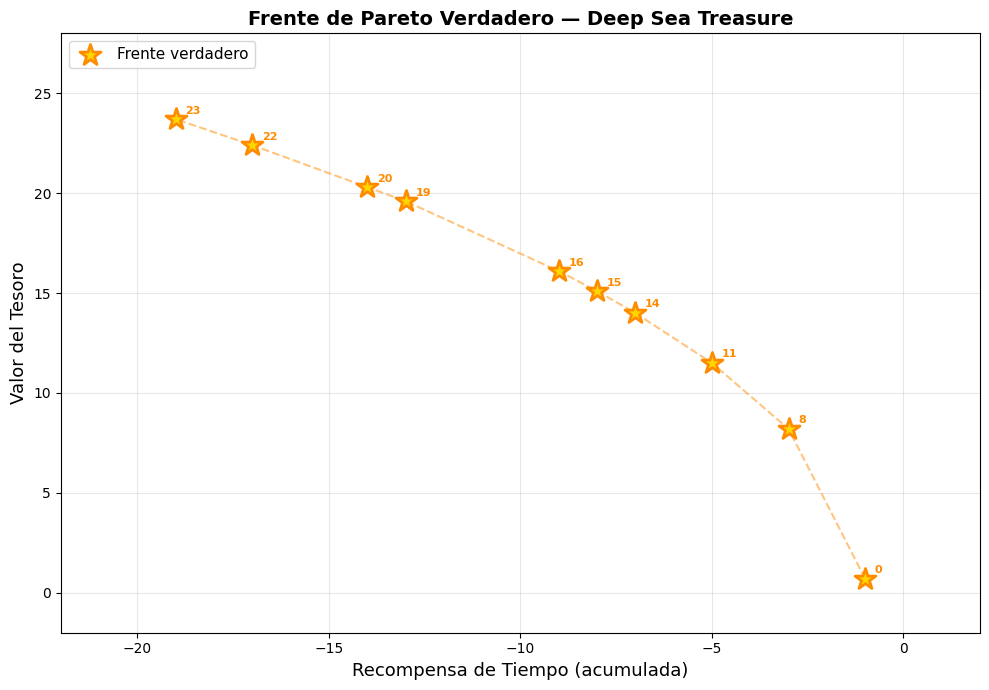

In [31]:
def plot_pareto_front(discovered=None, labels=None,
                      title='Frente de Pareto — Deep Sea Treasure'):
    """Visualiza el frente verdadero y frentes descubiertos superpuestos.
    Ejes: X = tiempo acumulado (negativo), Y = valor del tesoro (positivo).
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    pf = TRUE_PARETO  # columnas: [tiempo, tesoro]
    ax.scatter(pf[:, 0], pf[:, 1], s=250, c='gold', edgecolors='darkorange',
               linewidths=2, zorder=6, label='Frente verdadero', marker='*')
    ax.plot(pf[:, 0], pf[:, 1], '--', color='darkorange', alpha=0.5, lw=1.5, zorder=5)

    for t, v in pf:
        ax.annotate(f'{int(v)}', (t, v), textcoords='offset points',
                    xytext=(7, 4), fontsize=8, color='darkorange', fontweight='bold')

    palette = ['#2980b9', '#27ae60', '#e74c3c', '#8e44ad']
    markers  = ['o', 's', '^', 'D']
    if discovered:
        for i, (pts, lbl) in enumerate(zip(discovered, labels or [])):
            arr = np.array(pts)
            if len(arr):
                ax.scatter(arr[:, 0], arr[:, 1], s=110,
                           c=palette[i % 4], marker=markers[i % 4],
                           alpha=0.85, zorder=4, label=lbl,
                           edgecolors='black', linewidths=0.5)

    ax.set_xlabel('Recompensa de Tiempo (acumulada)', fontsize=13)
    ax.set_ylabel('Valor del Tesoro', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-22, 2)
    ax.set_ylim(-2, 28)
    plt.tight_layout()
    return fig


fig = plot_pareto_front(title='Frente de Pareto Verdadero — Deep Sea Treasure')
plt.savefig('videos/pareto_true.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Enfoque 1: Q-Learning con Escalarización Lineal

### Idea

Convertimos el vector de recompensas en un escalar usando pesos $\mathbf{w} = [w_1, w_2]$ con $w_1 + w_2 = 1$:

$$r_{\text{scalar}} = \mathbf{w}^\top \vec{r} = w_1 \cdot r_{\text{tiempo}} + w_2 \cdot r_{\text{tesoro}}$$

Luego aplicamos Q-Learning estándar:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ \mathbf{w}^\top \vec{r} + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

### Impacto de los Pesos

| Vector de pesos $\mathbf{w}$ | Comportamiento esperado |
|------------------------------|-------------------------|
| $[0.05,\ 0.95]$ | Prioriza el tesoro → va al más valioso (profundo) |
| $[0.50,\ 0.50]$ | Balance equitativo |
| $[0.90,\ 0.10]$ | Prioriza velocidad → va al tesoro más cercano |

### Limitación Clave

La escalarización lineal solo puede encontrar puntos en la **envolvente convexa** del frente de Pareto. Partes no convexas del frente son inaccesibles para cualquier combinación lineal de pesos.

In [32]:
class ScalarizedQLearning:
    """Q-Learning tabular con escalarización lineal para MORL.
    Nota: DST entrega recompensas en orden [tesoro, tiempo].
    El vector de pesos w = [w_tesoro, w_tiempo] se aplica en ese mismo orden.
    """

    def __init__(self, n_actions, weight, alpha=0.3, gamma=1.0,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9993):
        self.n_actions = n_actions
        self.w = np.array(weight, dtype=float)  # [w_tesoro, w_tiempo]
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: np.zeros(n_actions))

    def _key(self, obs):
        return tuple(np.asarray(obs, dtype=int))

    def select_action(self, obs, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[self._key(obs)]))

    def update(self, obs, action, r_vec, next_obs, done):
        s, s2 = self._key(obs), self._key(next_obs)
        # r_vec = [treasure, time]; dot product with w = [w_treasure, w_time]
        r = float(np.dot(self.w, r_vec))
        td_target = r if done else r + self.gamma * np.max(self.Q[s2])
        self.Q[s][action] += self.alpha * (td_target - self.Q[s][action])
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(self, env_id, n_episodes=3000, max_steps=200):
        """Retorna (hist_tiempo, hist_tesoro) — historial por episodio."""
        hist_t, hist_v = [], []
        for _ in range(n_episodes):
            env = mo_gym.make(env_id)
            obs, _ = env.reset()
            ep_time = ep_treasure = 0
            for _ in range(max_steps):
                a = self.select_action(obs)
                n_obs, r_vec, term, trunc, _ = env.step(a)
                self.update(obs, a, r_vec, n_obs, term or trunc)
                ep_time     += r_vec[1]  # tiempo: siempre -1
                ep_treasure += r_vec[0]  # tesoro: 0 o positivo al terminal
                obs = n_obs
                if term or trunc:
                    break
            env.close()
            hist_t.append(ep_time)
            hist_v.append(ep_treasure)
        return np.array(hist_t), np.array(hist_v)

    def evaluate(self, env_id, n_eval=20):
        """Retorna (mean_tiempo, mean_tesoro) para graficar en el frente de Pareto."""
        times, vals = [], []
        for _ in range(n_eval):
            env = mo_gym.make(env_id)
            obs, _ = env.reset()
            ep_time = ep_treasure = 0
            for _ in range(200):
                a = self.select_action(obs, greedy=True)
                obs, r_vec, term, trunc, _ = env.step(a)
                ep_time     += r_vec[1]  # tiempo acumulado (negativo)
                ep_treasure += r_vec[0]  # tesoro (positivo al final)
                if term or trunc:
                    break
            env.close()
            times.append(ep_time)
            vals.append(ep_treasure)
        # Retorna (tiempo, tesoro) → compatible con plot [tiempo, tesoro]
        return float(np.mean(times)), float(np.mean(vals))

In [33]:
# w = [w_tesoro, w_tiempo] con r = [tesoro, tiempo]
# Alto w_tiempo (r[1]<0 siempre) → penaliza pasos → política rápida (tesoros poco prof.)
# Alto w_tesoro (r[0]>0 al terminal) → prefiere alto valor → política profunda
WEIGHT_CONFIGS = [
    ([0.05, 0.95], 'w=[0.05,0.95] — Prioriza Tiempo (tesoro cercano)'),
    ([0.20, 0.80], 'w=[0.20,0.80]'),
    ([0.40, 0.60], 'w=[0.40,0.60]'),
    ([0.50, 0.50], 'w=[0.50,0.50] — Balanceado'),
    ([0.70, 0.30], 'w=[0.70,0.30]'),
    ([0.85, 0.15], 'w=[0.85,0.15] — Prioriza Tesoro (más valioso)'),
]

N_EPS = 4000
agents_s, results_s = [], []

print('Entrenando agentes con escalarización lineal...')
print('=' * 60)
for weight, label in WEIGHT_CONFIGS:
    agent = ScalarizedQLearning(
        n_actions=4, weight=weight,
        alpha=0.3, gamma=1.0,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9993
    )
    h_t, h_v = agent.train(ENV_ID, n_episodes=N_EPS)
    vt, vv = agent.evaluate(ENV_ID)  # vt=tiempo, vv=tesoro
    agents_s.append(agent)
    results_s.append(dict(weight=weight, label=label,
                           h_t=h_t, h_v=h_v, vt=vt, vv=vv))
    print(f'  {label:<45} tiempo={vt:>6.1f}  tesoro={vv:>6.1f}')

print('\nEntrenamiento completado.')

Entrenando agentes con escalarización lineal...
  w=[0.05,0.95] — Prioriza Tiempo (tesoro cercano) tiempo=  -1.0  tesoro=   0.7
  w=[0.20,0.80]                                 tiempo=  -1.0  tesoro=   0.7
  w=[0.40,0.60]                                 tiempo=  -5.0  tesoro=  11.5
  w=[0.50,0.50] — Balanceado                    tiempo=  -5.0  tesoro=  11.5
  w=[0.70,0.30]                                 tiempo=  -3.0  tesoro=   8.2
  w=[0.85,0.15] — Prioriza Tesoro (más valioso) tiempo=  -3.0  tesoro=   8.2

Entrenamiento completado.


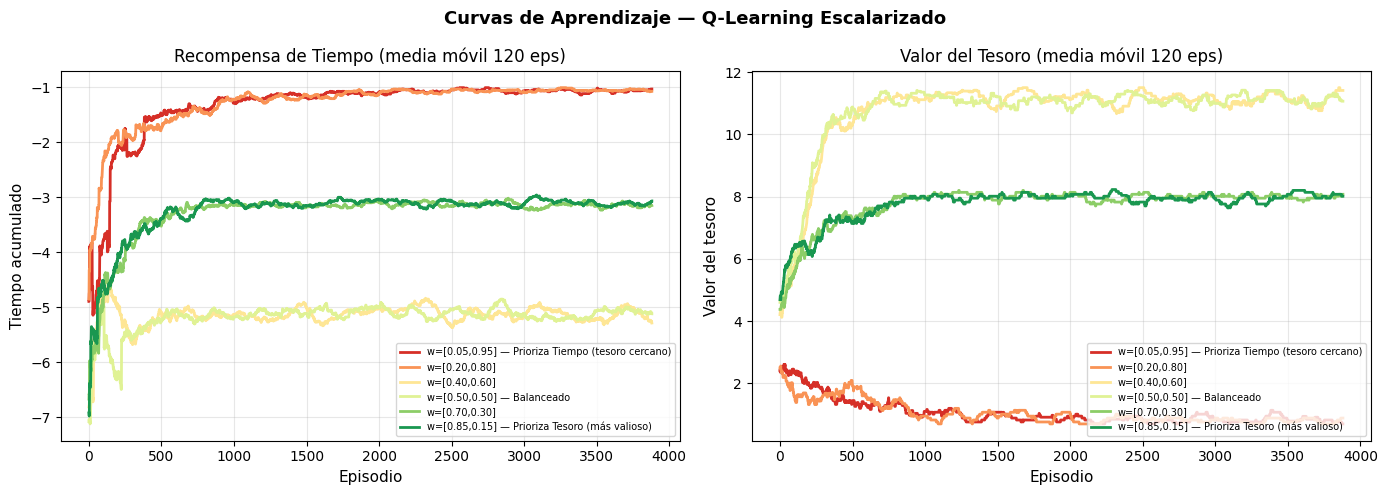

In [34]:
def smooth(x, w=120):
    return np.convolve(x, np.ones(w) / w, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(results_s)))

for i, res in enumerate(results_s):
    xs = range(len(smooth(res['h_t'])))
    axes[0].plot(xs, smooth(res['h_t']), color=colors[i], label=res['label'], lw=2)
    axes[1].plot(xs, smooth(res['h_v']), color=colors[i], label=res['label'], lw=2)

for ax, title, ylabel in zip(
    axes,
    ['Recompensa de Tiempo (media móvil 120 eps)',
     'Valor del Tesoro (media móvil 120 eps)'],
    ['Tiempo acumulado', 'Valor del tesoro']
):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Episodio', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Q-Learning Escalarizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('videos/learning_curves_scalar.png', dpi=100, bbox_inches='tight')
plt.show()

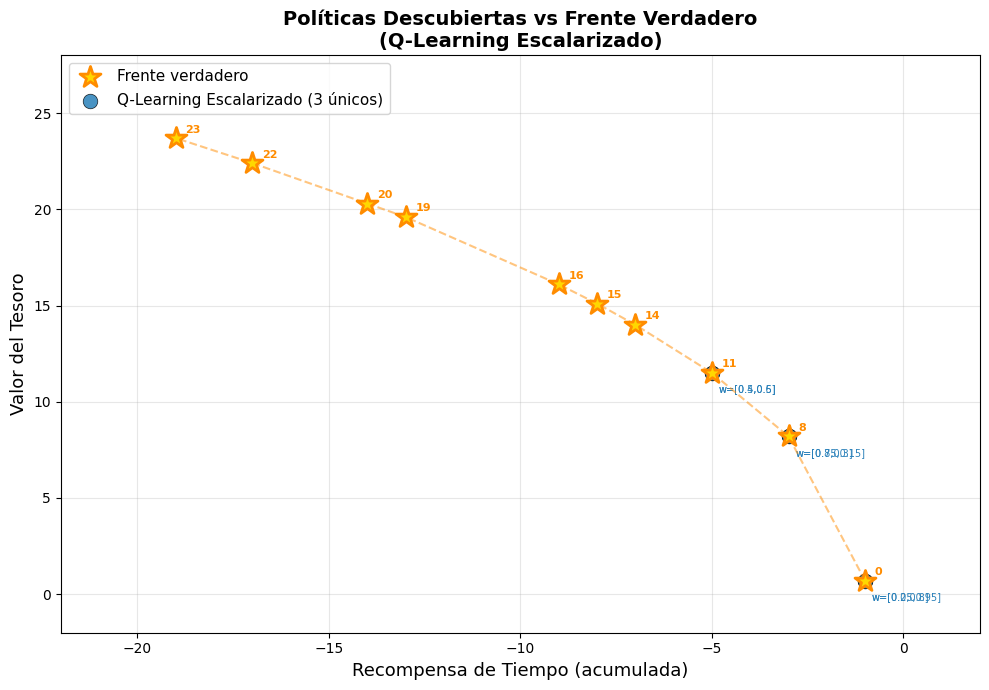


Políticas finales encontradas:
                 Pesos |   Tiempo |   Tesoro
----------------------------------------------
          [0.05, 0.95] |     -1.0 |      0.7
            [0.2, 0.8] |     -1.0 |      0.7
            [0.4, 0.6] |     -5.0 |     11.5
            [0.5, 0.5] |     -5.0 |     11.5
            [0.7, 0.3] |     -3.0 |      8.2
          [0.85, 0.15] |     -3.0 |      8.2


In [35]:
scalar_pts = [[r['vt'], r['vv']] for r in results_s]

fig = plot_pareto_front(
    discovered=[scalar_pts],
    labels=[f'Q-Learning Escalarizado ({len(set(map(tuple, scalar_pts)))} únicos)'],
    title='Políticas Descubiertas vs Frente Verdadero\n(Q-Learning Escalarizado)'
)
for res, pt in zip(results_s, scalar_pts):
    w = res['weight']
    plt.annotate(f"w=[{w[0]},{w[1]}]", pt,
                 textcoords='offset points', xytext=(5, -14),
                 fontsize=7, color='#2980b9')
plt.savefig('videos/pareto_scalar.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nPolíticas finales encontradas:')
print(f'{"Pesos":>22} | {"Tiempo":>8} | {"Tesoro":>8}')
print('-' * 46)
for res in results_s:
    print(f"{str(res['weight']):>22} | {res['vt']:>8.1f} | {res['vv']:>8.1f}")

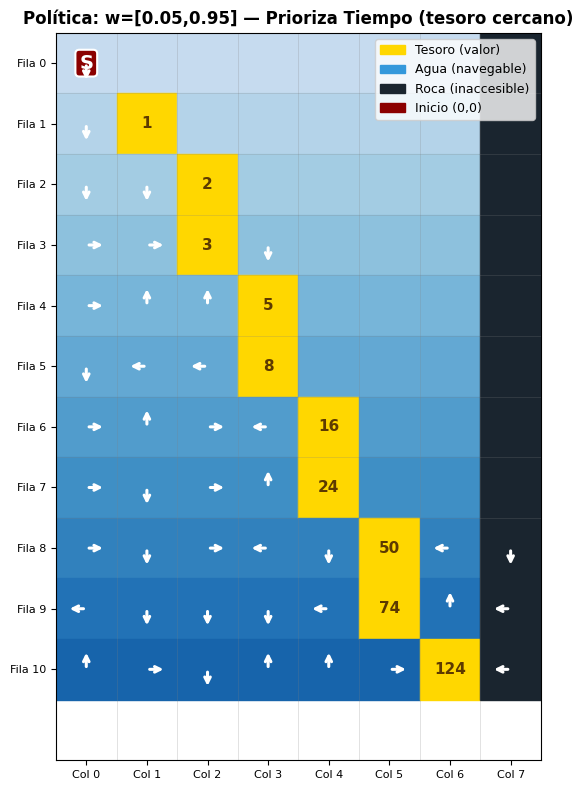

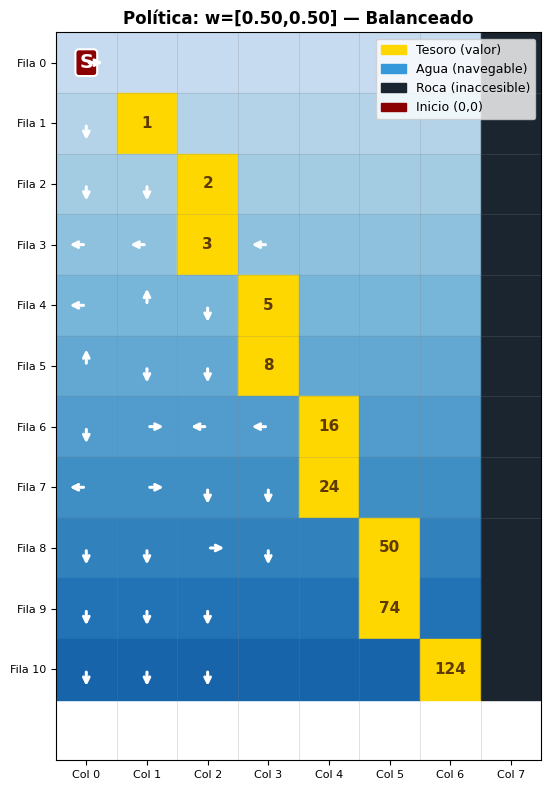

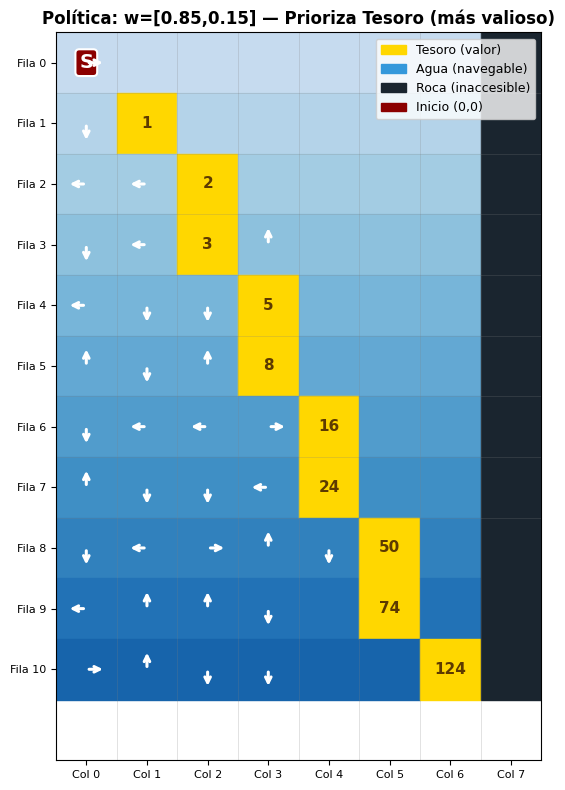

In [36]:
def plot_policy_arrows(agent, title='Política Aprendida'):
    """Visualiza la política como flechas sobre el mapa DST."""
    arrow_map = {0: (0, -0.32), 1: (0, 0.32), 2: (-0.32, 0), 3: (0.32, 0)}

    fig, ax = plt.subplots(figsize=(8, 8))
    plot_dst_map(ax=ax, show=False)

    for state_key, q_vals in agent.Q.items():
        col, row = state_key
        if not (0 <= col <= 7 and 0 <= row <= 10):
            continue
        if (col, row) in DST_TREASURES:
            continue
        best_a = int(np.argmax(q_vals))
        dx, dy = arrow_map[best_a]
        ax.annotate('', xy=(col + dx, row + dy), xytext=(col, row),
                    arrowprops=dict(arrowstyle='->', color='white', lw=2.2), zorder=5)

    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_policy_arrows(agents_s[0], f"Política: {results_s[0]['label']}")
plot_policy_arrows(agents_s[3], f"Política: {results_s[3]['label']}")
plot_policy_arrows(agents_s[5], f"Política: {results_s[5]['label']}")

In [37]:
print('Grabando videos de politicas aprendidas...')

video_indices = [0, 3, 5]  # prioriza tiempo, balanceado, prioriza tesoro
video_paths = []

for idx in video_indices:
    agent = agents_s[idx]
    w = results_s[idx]['weight']
    path = f"videos/scalar_{str(w[0]).replace('.','p')}_{str(w[1]).replace('.','p')}"
    video_paths.append(path)
    print(f"\n  Politica w={w}")
    record_episode(ENV_ID, lambda obs, a=agent: a.select_action(obs, greedy=True), path, fps=4)

print('\n--- Video 1: Prioriza Tiempo — tesoro cercano (w=[0.05, 0.95]) ---')
show_video(video_paths[0])
print('\n--- Video 2: Balanceado (w=[0.50, 0.50]) ---')
show_video(video_paths[1])
print('\n--- Video 3: Prioriza Tesoro — tesoro más valioso (w=[0.85, 0.15]) ---')
show_video(video_paths[2])

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Grabando videos de politicas aprendidas...

  Politica w=[0.05, 0.95]
  Video guardado: videos/scalar_0p05_0p95.mp4  (1 pasos, 2 frames)

  Politica w=[0.5, 0.5]


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/scalar_0p5_0p5.mp4  (5 pasos, 6 frames)

  Politica w=[0.85, 0.15]
  Video guardado: videos/scalar_0p85_0p15.mp4  (3 pasos, 4 frames)

--- Video 1: Prioriza Tiempo — tesoro cercano (w=[0.05, 0.95]) ---



--- Video 2: Balanceado (w=[0.50, 0.50]) ---



--- Video 3: Prioriza Tesoro — tesoro más valioso (w=[0.85, 0.15]) ---


## 7. Análisis del Impacto de los Parámetros

### Parámetros Clave

| Parámetro | Símbolo | Rol |
|-----------|---------|-----|
| Factor de descuento | $\gamma$ | Miopía del agente: $\gamma \to 0$ → solo recompensas inmediatas |
| Tasa de aprendizaje | $\alpha$ | Velocidad de actualización de Q |
| Exploración | $\varepsilon$ (epsilon-greedy) | Balance exploración–explotación |
| Pesos | $\mathbf{w}$ | Punto del frente de Pareto que se busca |

### Impacto de $\gamma$

$$G_t = r_{t+1} + \gamma\, r_{t+2} + \gamma^2\, r_{t+3} + \cdots$$

- **$\gamma \to 0$**: agente miope, prefiere tesoros cercanos aunque sean de bajo valor
- **$\gamma = 1$**: agente con visión completa, puede aprender a navegar hasta tesoros lejanos y valiosos

Analizando impacto de gamma (w=[0.3, 0.7], 4000 episodios)...
  gamma=0.80  →  tiempo=-3.0  tesoro=8.2
  gamma=0.90  →  tiempo=-3.0  tesoro=8.2
  gamma=0.98  →  tiempo=-3.0  tesoro=8.2
  gamma=1.00  →  tiempo=-3.0  tesoro=8.2


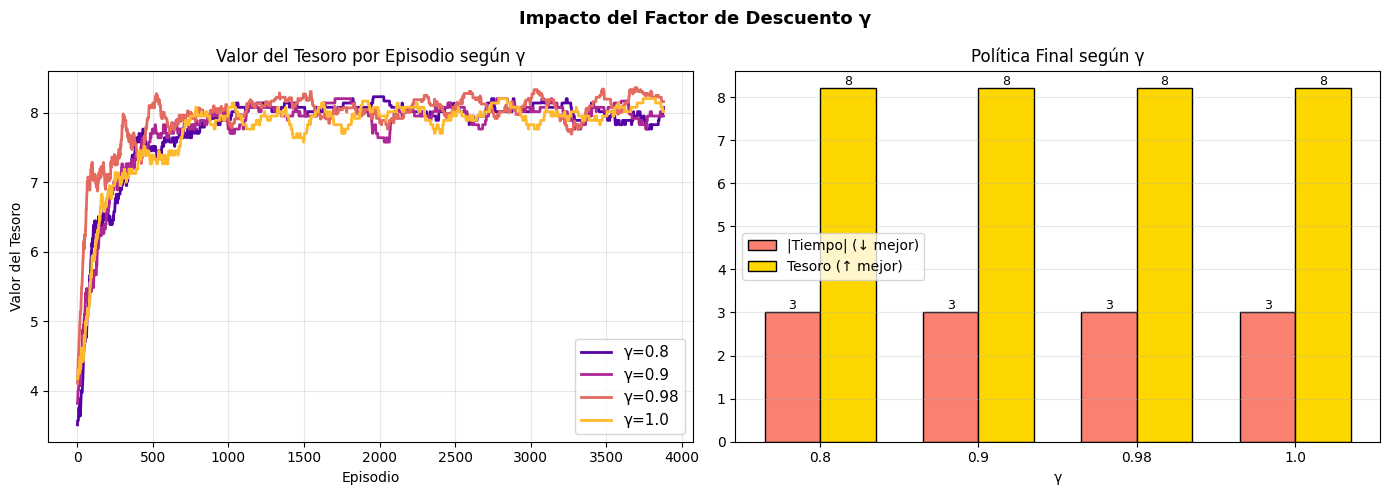


Observacion: gamma bajo = miopía = tesoros poco profundos.
gamma=1.0 permite encontrar tesoros más valiosos y profundos.


In [38]:
GAMMA_VALUES = [0.80, 0.90, 0.98, 1.0]
FIXED_WEIGHT = [0.3, 0.7]
gamma_results = []

print(f'Analizando impacto de gamma (w={FIXED_WEIGHT}, {N_EPS} episodios)...')
for g in GAMMA_VALUES:
    agent = ScalarizedQLearning(
        n_actions=4, weight=FIXED_WEIGHT,
        alpha=0.3, gamma=g,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9993
    )
    _, h_v = agent.train(ENV_ID, n_episodes=N_EPS)
    vt, vv = agent.evaluate(ENV_ID)
    gamma_results.append(dict(gamma=g, h_v=h_v, vt=vt, vv=vv))
    print(f'  gamma={g:.2f}  →  tiempo={vt:.1f}  tesoro={vv:.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_g = plt.cm.plasma(np.linspace(0.15, 0.85, len(GAMMA_VALUES)))

for i, res in enumerate(gamma_results):
    ax1.plot(smooth(res['h_v'], 120), color=colors_g[i],
             label=f"γ={res['gamma']}", lw=2)

ax1.set_title('Valor del Tesoro por Episodio según γ', fontsize=12)
ax1.set_xlabel('Episodio'); ax1.set_ylabel('Valor del Tesoro')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

gammas = [r['gamma'] for r in gamma_results]
treasures_g = [r['vv'] for r in gamma_results]
times_g = [abs(r['vt']) for r in gamma_results]
x = np.arange(len(gammas))
w_bar = 0.35
ax2.bar(x - w_bar/2, times_g, w_bar, label='|Tiempo| (↓ mejor)', color='salmon', edgecolor='black')
ax2.bar(x + w_bar/2, treasures_g, w_bar, label='Tesoro (↑ mejor)', color='gold', edgecolor='black')
ax2.set_xticks(x); ax2.set_xticklabels([str(g) for g in gammas])
ax2.set_title('Política Final según γ', fontsize=12)
ax2.set_xlabel('γ'); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, axis='y')
for bars in ax2.containers:
    ax2.bar_label(bars, fmt='%.0f', fontsize=9)

plt.suptitle('Impacto del Factor de Descuento γ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('videos/gamma_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nObservacion: gamma bajo = miopía = tesoros poco profundos.')
print('gamma=1.0 permite encontrar tesoros más valiosos y profundos.')

Analizando impacto de alpha...
  alpha=0.05 completado
  alpha=0.15 completado
  alpha=0.3 completado
  alpha=0.5 completado


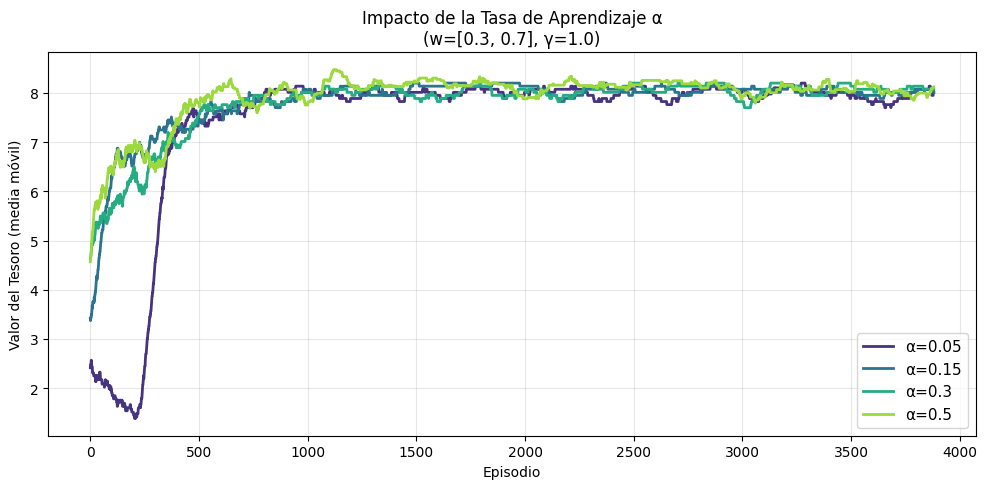

α pequeño → convergencia lenta pero estable.
α grande → aprendizaje rápido pero puede oscilar.


In [39]:
ALPHA_VALUES = [0.05, 0.15, 0.30, 0.50]
alpha_results = []

print('Analizando impacto de alpha...')
for a in ALPHA_VALUES:
    agent = ScalarizedQLearning(
        n_actions=4, weight=[0.3, 0.7],
        alpha=a, gamma=1.0,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9993
    )
    _, h_v = agent.train(ENV_ID, n_episodes=N_EPS)
    alpha_results.append(dict(alpha=a, h_v=h_v))
    print(f'  alpha={a} completado')

fig, ax = plt.subplots(figsize=(10, 5))
colors_a = plt.cm.viridis(np.linspace(0.15, 0.85, len(ALPHA_VALUES)))

for i, res in enumerate(alpha_results):
    ax.plot(smooth(res['h_v'], 120), color=colors_a[i],
            label=f"α={res['alpha']}", lw=2)

ax.set_title('Impacto de la Tasa de Aprendizaje α\n(w=[0.3, 0.7], γ=1.0)', fontsize=12)
ax.set_xlabel('Episodio'); ax.set_ylabel('Valor del Tesoro (media móvil)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('videos/alpha_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('α pequeño → convergencia lenta pero estable.')
print('α grande → aprendizaje rápido pero puede oscilar.')

Analizando impacto del decaimiento de epsilon...
  decay=0.998  eps→min en episodio ~1496
  decay=0.999  eps→min en episodio ~2994
  decay=0.9993  eps→min en episodio ~4278
  decay=0.9998  eps→min en episodio ~14977


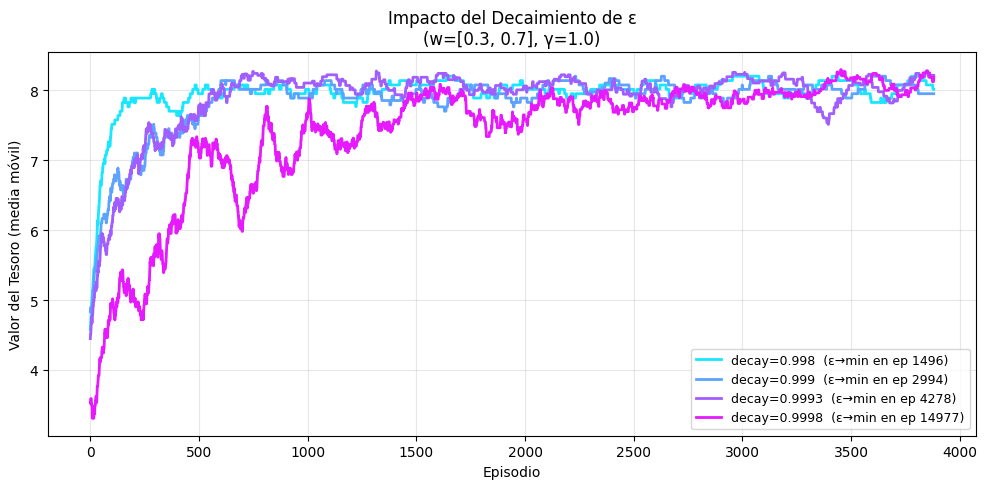

Decay muy rapido → poca exploración → queda atrapado en políticas subóptimas.
Decay lento → exploración prolongada → converge más tarde pero a mejor política.


In [40]:
# Impacto del decaimiento de epsilon
DECAY_VALUES = [0.9980, 0.9990, 0.9993, 0.9998]
decay_results = []

print('Analizando impacto del decaimiento de epsilon...')
for decay in DECAY_VALUES:
    agent = ScalarizedQLearning(
        n_actions=4, weight=[0.3, 0.7],
        alpha=0.3, gamma=1.0,
        epsilon=1.0, epsilon_min=0.05, epsilon_decay=decay
    )
    _, h_v = agent.train(ENV_ID, n_episodes=N_EPS)
    # Calcular episodio en que epsilon llega al mínimo
    eps_thresh = np.log(0.05 / 1.0) / np.log(decay)
    decay_results.append(dict(decay=decay, h_v=h_v, eps_thresh=int(eps_thresh)))
    print(f'  decay={decay}  eps→min en episodio ~{int(eps_thresh)}')

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = plt.cm.cool(np.linspace(0.1, 0.9, len(DECAY_VALUES)))

for i, res in enumerate(decay_results):
    ax.plot(smooth(res['h_v'], 120), color=colors_d[i],
            label=f"decay={res['decay']}  (ε→min en ep {res['eps_thresh']})", lw=2)

ax.set_title('Impacto del Decaimiento de ε\n(w=[0.3, 0.7], γ=1.0)', fontsize=12)
ax.set_xlabel('Episodio'); ax.set_ylabel('Valor del Tesoro (media móvil)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('videos/epsilon_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('Decay muy rapido → poca exploración → queda atrapado en políticas subóptimas.')
print('Decay lento → exploración prolongada → converge más tarde pero a mejor política.')

## 8. Enfoque 2: Pareto Q-Learning (PQL)

### ¿Cómo funciona PQL?

Pareto Q-Learning (Vamplew et al., 2011) es un algoritmo **multi-política** que descubre el **frente de Pareto completo** en una sola sesión de entrenamiento.

#### Idea Central

En lugar de un escalar $Q(s, a) \in \mathbb{R}$, PQL mantiene un **conjunto de vectores Q no dominados** por cada par $(s, a)$:

$$\hat{Q}(s, a) = \{\vec{q}_1, \vec{q}_2, \ldots, \vec{q}_k\} \subset \mathbb{R}^n$$

Cada $\vec{q}_i$ representa una combinación de recompensas acumuladas Pareto-óptima.

#### Regla de Actualización

$$\hat{Q}(s, a) \leftarrow \text{ND}\left(\hat{Q}(s, a) \cup \left\{\vec{r} + \gamma \cdot \vec{q} \mid \vec{q} \in \bigcup_{a'} \hat{Q}(s', a')\right\}\right)$$

donde $\text{ND}(\cdot)$ conserva solo los vectores no dominados.

#### Métricas de Evaluación

**Hipervolumen**: mide el espacio dominado por el frente encontrado respecto al punto de referencia $\mathbf{r}_{\text{ref}}$:

$$HV(\mathcal{F},\, \mathbf{r}_{\text{ref}}) = \lambda\!\left(\bigcup_{\vec{v} \in \mathcal{F}} [\vec{v},\, \mathbf{r}_{\text{ref}}]\right)$$

#### Ventajas y Desventajas vs Escalarización

| Aspecto | Escalarización | PQL |
|---------|---------------|-----|
| Frente encontrado | Solo envolvente convexa | Frente completo |
| Pesos requeridos | Sí, a priori | No |
| Costo computacional | Bajo (una tabla Q) | Mayor (tabla de conjuntos) |
| Escala a espacios grandes | Bien | Limitado (tabular) |
| Punto de referencia | No | Sí (para hipervolumen) |

In [41]:

GAMMA_PQL = 1.0
REF_POINT = np.array([0.0, -25.0])
PQL_TIMESTEPS = 150000

print('Configurando PQL...')
print(f'  gamma     = {GAMMA_PQL}')
print(f'  ref_point = {REF_POINT}')
print(f'  timesteps = {PQL_TIMESTEPS:,}')

env_pql = mo_gym.make(ENV_ID)
env_pql = MORecordEpisodeStatistics(env_pql, gamma=GAMMA_PQL)
eval_env_pql = mo_gym.make(ENV_ID)

agent_pql = PQL(
    env=env_pql,
    ref_point=REF_POINT,
    gamma=GAMMA_PQL,
    log=False,
)

print('\nEntrenando PQL (puede tardar unos minutos)...')
agent_pql.train(
    total_timesteps=PQL_TIMESTEPS,
    eval_env=eval_env_pql,
    ref_point=REF_POINT,
)
print('Entrenamiento PQL completado.')

env_pql.close()
eval_env_pql.close()

Configurando PQL...
  gamma     = 1.0
  ref_point = [  0. -25.]
  timesteps = 150,000

Entrenando PQL (puede tardar unos minutos)...
Entrenamiento PQL completado.


Frente de Pareto aprendido por PQL (tabla Q interna, estado inicial):
    Tiempo |     Tesoro
-------------------------
     -19.0 |       23.7
     -17.0 |       22.4
     -14.0 |       20.3
     -13.0 |       19.6
      -9.0 |       16.1
      -8.0 |       15.1
      -7.0 |       14.0
      -5.0 |       11.5
      -3.0 |        8.2
      -1.0 |        0.7

Puntos Pareto-óptimos descubiertos: 10 / 10


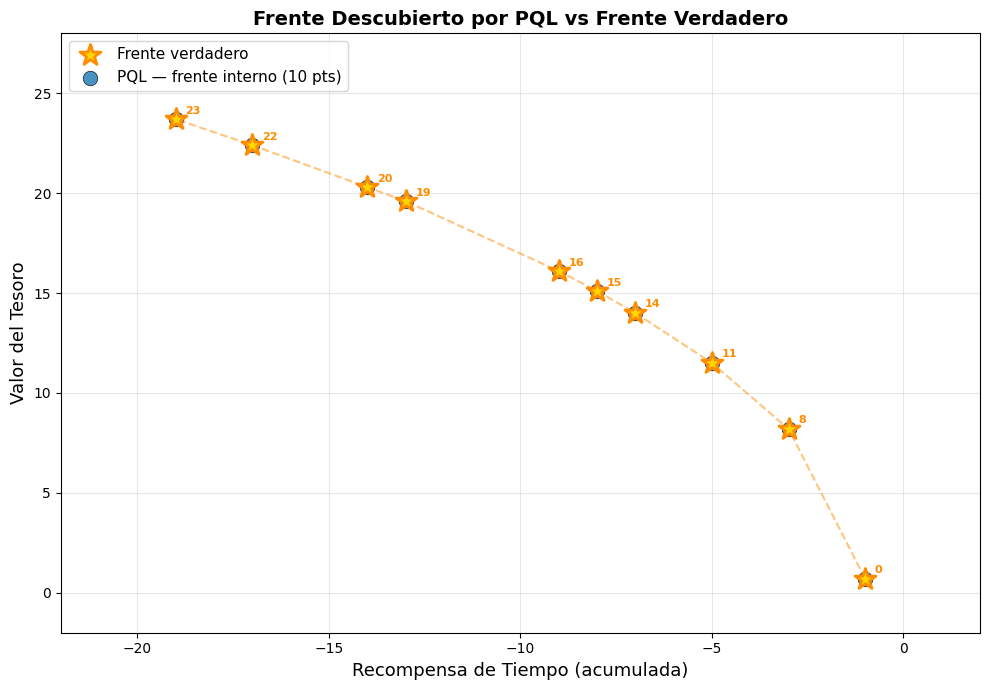

In [42]:
EVAL_WEIGHTS = [
    np.array([0.02, 0.98]),
    np.array([0.08, 0.92]),
    np.array([0.15, 0.85]),
    np.array([0.25, 0.75]),
    np.array([0.35, 0.65]),
    np.array([0.50, 0.50]),
    np.array([0.60, 0.40]),
    np.array([0.70, 0.30]),
    np.array([0.80, 0.20]),
    np.array([0.92, 0.08]),
]

# Extraer el frente de Pareto directamente de la tabla Q interna de PQL
# (en lugar de evaluar con trayectorias ruidosas de score_hypervolume)
from morl_baselines.common.pareto import get_non_dominated

start_state = int(np.ravel_multi_index([0, 0], agent_pql.env_shape))
internal_front = agent_pql.calc_non_dominated(start_state)

# El ambiente retorna r_vec = [tesoro, tiempo]  →  intercambiamos a [tiempo, tesoro] para el plot
pql_unique = [[v[1], v[0]] for v in internal_front]

print('Frente de Pareto aprendido por PQL (tabla Q interna, estado inicial):')
print(f'{"Tiempo":>10} | {"Tesoro":>10}')
print('-' * 25)
for t, v in sorted(pql_unique):
    print(f'{t:>10.1f} | {v:>10.1f}')

print(f'\nPuntos Pareto-óptimos descubiertos: {len(pql_unique)} / {len(TRUE_PARETO)}')

fig = plot_pareto_front(
    discovered=[pql_unique],
    labels=[f'PQL — frente interno ({len(pql_unique)} pts)'],
    title='Frente Descubierto por PQL vs Frente Verdadero'
)
plt.savefig('videos/pareto_pql.png', dpi=100, bbox_inches='tight')
plt.show()

In [43]:
print('Grabando videos de las politicas PQL...')

def pql_policy(obs):
    state_int = int(np.ravel_multi_index(obs, agent_pql.env_shape))
    return agent_pql.select_action(state_int, agent_pql.score_hypervolume)

record_episode(ENV_ID, pql_policy, 'videos/pql_hypervolume', fps=4)
record_episode(ENV_ID, pql_policy, 'videos/pql_hypervolume2', fps=4)
record_episode(ENV_ID, pql_policy, 'videos/pql_hypervolume3', fps=4)

print('\n--- PQL: Episodio 1 ---')
show_video('videos/pql_hypervolume')
print('\n--- PQL: Episodio 2 ---')
show_video('videos/pql_hypervolume2')
print('\n--- PQL: Episodio 3 ---')
show_video('videos/pql_hypervolume3')
print('\nNota: PQL puede elegir diferentes tesoros en cada episodio,')
print('ya que mantiene multiples politicas Pareto-optimas simultaneamente.')

Grabando videos de las politicas PQL...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/pql_hypervolume.mp4  (5 pasos, 6 frames)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (532, 512) to (544, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Video guardado: videos/pql_hypervolume2.mp4  (71 pasos, 72 frames)
  Video guardado: videos/pql_hypervolume3.mp4  (8 pasos, 9 frames)

--- PQL: Episodio 1 ---



--- PQL: Episodio 2 ---



--- PQL: Episodio 3 ---



Nota: PQL puede elegir diferentes tesoros en cada episodio,
ya que mantiene multiples politicas Pareto-optimas simultaneamente.


## 9. Análisis de Parámetros del PQL

### Punto de Referencia ($\mathbf{r}_{\text{ref}}$)

El punto de referencia define el espacio de hipervolumen. Debe ser **estrictamente peor** que cualquier punto del frente de Pareto.

- **Muy cercano al frente**: el hipervolumen es pequeño → el agente no explora suficiente
- **Muy lejano**: el hipervolumen captura regiones irrelevantes → señal de aprendizaje diluida

**Regla práctica**: usar el peor valor posible de cada objetivo con un margen de ~20%.

### Factor de Descuento ($\gamma$)

En el DST con episodios cortos y $\gamma = 1.0$, el agente puede aprender políticas para todos los tesoros. Con $\gamma < 1$, los tesoros profundos son subvalorados porque su recompensa de tiempo se descuenta más.

Analizando impacto del punto de referencia en PQL...
  ref_point=[ 0. -5.]  →  2 politicas unicas
  ref_point=[  0. -25.]  →  10 politicas unicas
  ref_point=[  0. -50.]  →  10 politicas unicas


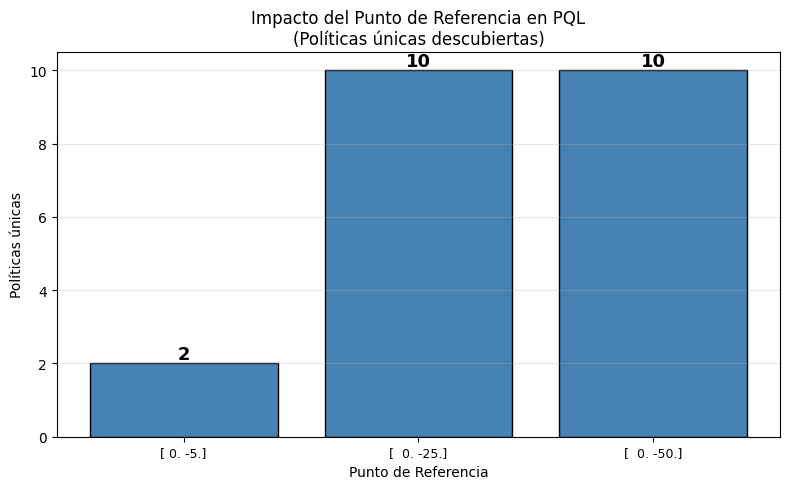

In [44]:
REF_POINTS_TEST = [
    np.array([0.0, -5.0]),
    np.array([0.0, -25.0]),
    np.array([0.0, -50.0]),
]

rp_results = {}

print('Analizando impacto del punto de referencia en PQL...')
for rp in REF_POINTS_TEST:
    env_r = mo_gym.make(ENV_ID)
    env_r = MORecordEpisodeStatistics(env_r, gamma=1.0)
    ev_r  = mo_gym.make(ENV_ID)

    ag = PQL(env=env_r, ref_point=rp, gamma=1.0, log=False)
    ag.train(total_timesteps=100000, eval_env=ev_r, ref_point=rp)

    ev2 = mo_gym.make(ENV_ID)
    policies = set()
    for w in EVAL_WEIGHTS:
        ep_t = ep_v = 0
        obs, _ = ev2.reset()
        for _ in range(200):
            state_int = int(np.ravel_multi_index(obs, ag.env_shape))
            a = ag.select_action(state_int, ag.score_hypervolume)
            obs, r_vec, term, trunc, _ = ev2.step(a)
            ep_t += r_vec[1]  # tiempo
            ep_v += r_vec[0]  # tesoro
            if term or trunc: break
        policies.add((round(ep_t, 0), round(ep_v, 0)))
    ev2.close(); env_r.close(); ev_r.close()

    rp_results[str(rp)] = len(policies)
    print(f'  ref_point={rp}  →  {len(policies)} politicas unicas')

fig, ax = plt.subplots(figsize=(8, 5))
rp_labels = [str(r) for r in REF_POINTS_TEST]
counts = [rp_results[k] for k in rp_labels]
bars = ax.bar(range(len(rp_labels)), counts, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(rp_labels)))
ax.set_xticklabels(rp_labels, fontsize=9)
ax.set_title('Impacto del Punto de Referencia en PQL\n(Políticas únicas descubiertas)', fontsize=12)
ax.set_xlabel('Punto de Referencia'); ax.set_ylabel('Políticas únicas')
ax.bar_label(bars, fmt='%d', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('videos/pql_refpoint.png', dpi=100, bbox_inches='tight')
plt.show()

Analizando impacto de gamma en PQL...
  gamma=0.85  →  3 politicas  |  max tesoro=11.5
  gamma=0.95  →  2 politicas  |  max tesoro=14.0
  gamma=1.0  →  10 politicas  |  max tesoro=20.299999237060547


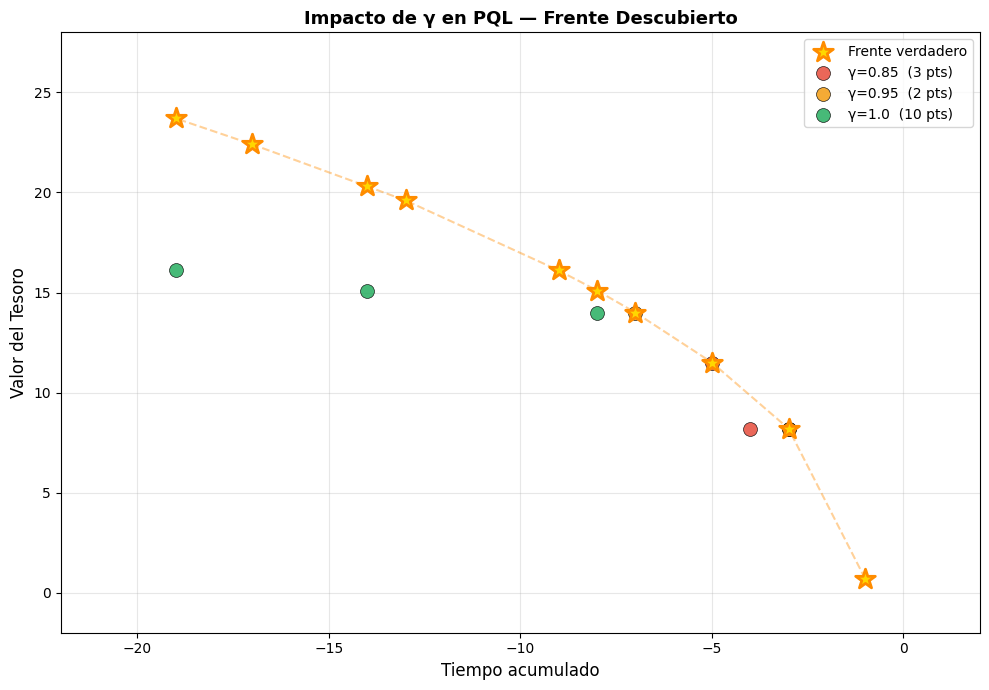

gamma=1.0 permite a PQL valorar igualmente tesoros a cualquier profundidad.


In [45]:
GAMMA_PQL_TEST = [0.85, 0.95, 1.0]
gamma_pql_results = []

print('Analizando impacto de gamma en PQL...')
for g in GAMMA_PQL_TEST:
    env_g = mo_gym.make(ENV_ID)
    env_g = MORecordEpisodeStatistics(env_g, gamma=g)
    ev_g  = mo_gym.make(ENV_ID)

    ag = PQL(env=env_g, ref_point=REF_POINT, gamma=g, log=False)
    ag.train(total_timesteps=100000, eval_env=ev_g, ref_point=REF_POINT)

    ev2 = mo_gym.make(ENV_ID)
    pts = []
    for w in EVAL_WEIGHTS:
        ep_t = ep_v = 0
        obs, _ = ev2.reset()
        for _ in range(200):
            state_int = int(np.ravel_multi_index(obs, ag.env_shape))
            a = ag.select_action(state_int, ag.score_hypervolume)
            obs, r_vec, term, trunc, _ = ev2.step(a)
            ep_t += r_vec[1]  # tiempo
            ep_v += r_vec[0]  # tesoro
            if term or trunc: break
        pts.append([ep_t, ep_v])
    ev2.close(); env_g.close(); ev_g.close()

    uniq = list({tuple(p) for p in pts})
    gamma_pql_results.append(dict(gamma=g, pts=uniq))
    max_t = max(p[1] for p in uniq)
    print(f'  gamma={g}  →  {len(uniq)} politicas  |  max tesoro={max_t}')

palette2 = ['#e74c3c', '#f39c12', '#27ae60']
fig, ax = plt.subplots(figsize=(10, 7))

pf = TRUE_PARETO
ax.scatter(pf[:, 0], pf[:, 1], s=220, c='gold', edgecolors='darkorange',
           linewidths=2, zorder=6, label='Frente verdadero', marker='*')
ax.plot(pf[:, 0], pf[:, 1], '--', color='darkorange', alpha=0.4, lw=1.5)

for i, res in enumerate(gamma_pql_results):
    arr = np.array(res['pts'])
    ax.scatter(arr[:, 0], arr[:, 1], s=100, c=palette2[i],
               label=f"γ={res['gamma']}  ({len(res['pts'])} pts)",
               alpha=0.85, zorder=4, edgecolors='black', lw=0.5)

ax.set_xlabel('Tiempo acumulado', fontsize=12)
ax.set_ylabel('Valor del Tesoro', fontsize=12)
ax.set_title('Impacto de γ en PQL — Frente Descubierto', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-22, 2); ax.set_ylim(-2, 28)
plt.tight_layout()
plt.savefig('videos/pql_gamma.png', dpi=100, bbox_inches='tight')
plt.show()

print('gamma=1.0 permite a PQL valorar igualmente tesoros a cualquier profundidad.')

## 10. Comparación Final: Escalarización vs PQL

        COMPARACIÓN: Q-LEARNING ESCALARIZADO vs PQL
  Métrica                                  |  Escalar |      PQL
-----------------------------------------------------------------
  Políticas únicas encontradas             |        3 |       10
  Cobertura del frente verdadero (%)       |      30% |     100%
  Max tesoro alcanzado                     |       12 |       24
  Requiere pesos a priori                  |       Sí |       No
  Cubre partes no convexas                 |       No |       Sí
  Episodios/pasos entrenamiento            |   24,000 |  150,000


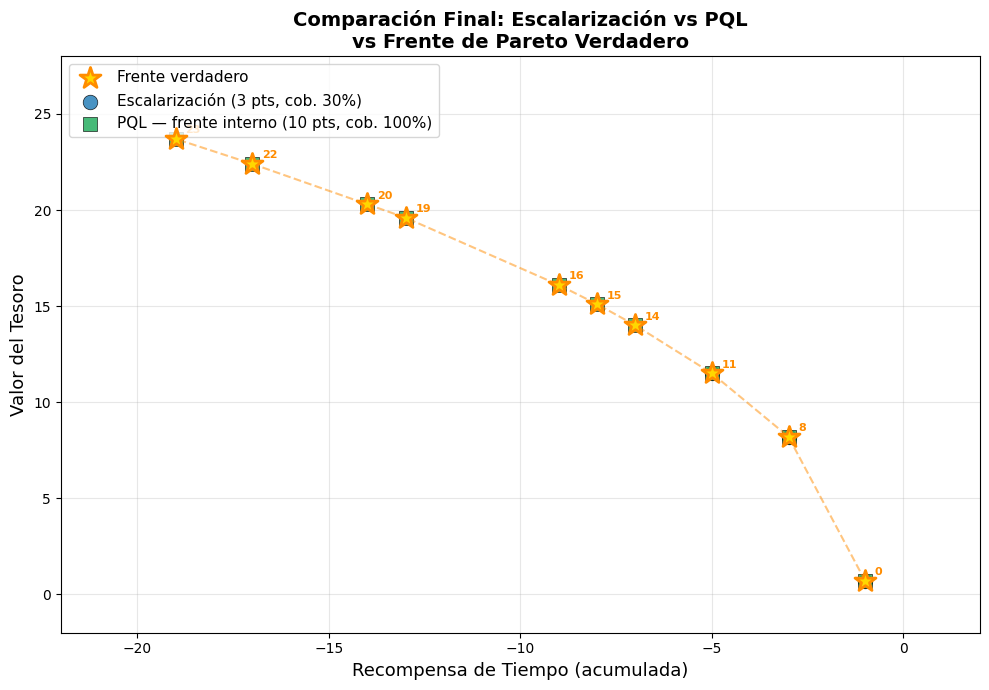

In [46]:
def pareto_coverage(discovered, true_front=TRUE_PARETO, tol=1.5):
    """Porcentaje de puntos verdaderos cubiertos por el frente descubierto."""
    covered = 0
    for pt in true_front:
        if any(abs(d[0] - pt[0]) < tol and abs(d[1] - pt[1]) < tol
               for d in discovered):
            covered += 1
    return 100.0 * covered / len(true_front)


scalar_unique = list({tuple(p) for p in scalar_pts})
s_cov = pareto_coverage(scalar_unique)
p_cov = pareto_coverage(pql_unique)

print('=' * 65)
print('        COMPARACIÓN: Q-LEARNING ESCALARIZADO vs PQL')
print('=' * 65)
print(f'  {"Métrica":<40} | {"Escalar":>8} | {"PQL":>8}')
print('-' * 65)
print(f'  {"Políticas únicas encontradas":<40} | {len(scalar_unique):>8} | {len(pql_unique):>8}')
print(f'  {"Cobertura del frente verdadero (%)":<40} | {s_cov:>7.0f}% | {p_cov:>7.0f}%')
print(f'  {"Max tesoro alcanzado":<40} | {max(p[1] for p in scalar_unique):>8.0f} | {max(p[1] for p in pql_unique):>8.0f}')
print(f'  {"Requiere pesos a priori":<40} | {"Sí":>8} | {"No":>8}')
print(f'  {"Cubre partes no convexas":<40} | {"No":>8} | {"Sí":>8}')
print(f'  {"Episodios/pasos entrenamiento":<40} | {N_EPS*len(WEIGHT_CONFIGS):>8,} | {PQL_TIMESTEPS:>8,}')

fig = plot_pareto_front(
    discovered=[scalar_unique, pql_unique],
    labels=[
        f'Escalarización ({len(scalar_unique)} pts, cob. {s_cov:.0f}%)',
        f'PQL — frente interno ({len(pql_unique)} pts, cob. {p_cov:.0f}%)',
    ],
    title='Comparación Final: Escalarización vs PQL\nvs Frente de Pareto Verdadero'
)
plt.savefig('videos/pareto_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Conclusiones

### ¿Qué aprendimos?

**1. MORL vs RL Clásico**  
Cuando los objetivos están en conflicto, no existe una única política óptima. MORL permite representar y razonar sobre todo el conjunto de soluciones no dominadas.

**2. Deep Sea Treasure como Benchmark**  
El DST es ideal para MORL porque:
- El frente de Pareto es conocido analíticamente
- El trade-off tiempo–tesoro es intuitivo y visualizable
- El espacio de estados es pequeño → permite métodos tabulares

**3. Q-Learning con Escalarización Lineal**  
- Sencillo de implementar y computacionalmente eficiente  
- Requiere saber de antemano qué preferencias tiene el decisor  
- Solo encuentra puntos en la **envolvente convexa** del frente  
- Apropiado cuando las preferencias están definidas y el frente es convexo  

**4. Pareto Q-Learning (PQL)**  
- Descubre el frente completo en una sola sesión de entrenamiento  
- No requiere especificar preferencias a priori  
- Mayor costo computacional (tablas de conjuntos de vectores)  
- Apropiado cuando se desconocen las preferencias del decisor  

### Impacto de los Parámetros

| Parámetro | Recomendación para DST | Por qué |
|-----------|------------------------|----------|
| $\gamma$ | $1.0$ | Episodios cortos; sin descuento el agente aprecia todos los tesoros por igual |
| $\alpha$ | $[0.2, 0.4]$ | Balance velocidad/estabilidad en tabla Q |
| $\varepsilon$-decay | Lento (~0.9993) | Exploración suficiente para descubrir tesoros lejanos |
| ref\_point (PQL) | $[0, -25]$ | Peor que cualquier política óptima del frente |

### Limitaciones y Trabajo Futuro

- **GPI-LS / GPI-PD**: Combinan mejora de política generalizada con soporte lineal — más eficientes que PQL para espacios de estados grandes  
- **MORL con función de valor (redes neuronales)**: Para espacios continuos como MO-MuJoCo o Minecart  
- **Preferencias dinámicas**: Algoritmos condicionados en preferencias (PCN) que adaptan la política a nuevas preferencias sin reentrenamiento  

---

### Referencias

- Vamplew et al. (2011). *Empirical evaluation methods for multi-objective reinforcement learning algorithms.* Machine Learning.
- Van Moffaert & Nowé (2014). *Multi-objective reinforcement learning using sets of Pareto dominating policies.* JMLR.
- Alegre et al. (2022). *MORL-Baselines: A Collection of Multi-Objective Reinforcement Learning Algorithms.* JAIR.
- MO-Gymnasium: https://mo-gymnasium.farama.org/
- MORL-Baselines: https://lucasalegre.github.io/morl-baselines/